<a href="https://colab.research.google.com/github/varaiitj2527/PRMLProject/blob/main/Model/Decision_Tree/DecisionTree_Entropy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!git clone https://github.com/varaiitj2527/PRMLProject.git
%cd PRMLProject

Cloning into 'PRMLProject'...
remote: Enumerating objects: 48, done.
remote: Counting objects: 100% (30/30), done.
remote: Compressing objects: 100% (26/26), done.
remote: Total 48 (delta 3), reused 15 (delta 0), pack-reused 18 (from 2)
Receiving objects: 100% (48/48), 162.58 MiB | 11.16 MiB/s, done.
Resolving deltas: 100% (3/3), done.
Updating files: 100% (25/25), done.
Filtering content: 100% (12/12), 851.90 MiB | 59.90 MiB/s, done.
/content/PRMLProject


In [ ]:
import numpy as np
from skimage.feature import hog
from tqdm import tqdm
import pickle
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score, GridSearchCV
import matplotlib.pyplot as plt

In [ ]:
def unpickle(filename) :

  with open(filename, 'rb') as file :
      data = pickle.load(file, encoding='bytes')

  return data

In [ ]:
train_RawData = unpickle('PreProcessedData/RawPixels_train.pkl')
test_RawData = unpickle('PreProcessedData/RawPixels_test.pkl')

train_labels = unpickle('PreProcessedData/Labels_train.pkl')
test_labels = unpickle('PreProcessedData/Labels_test.pkl')

train_PcaData = unpickle('PreProcessedData/TrainFeaturesPCA.pkl')
test_PcaData = unpickle('PreProcessedData/TestFeaturesPCA.pkl')

train_HoGData = unpickle('PreProcessedData/TrainFeaturesHoG.pkl')
test_HoGData = unpickle('PreProcessedData/TestFeaturesHoG.pkl')

train_Pca_HoGData = unpickle('PreProcessedData/TrainFeaturesPCA_HoG.pkl')
test_Pca_HoGData = unpickle('PreProcessedData/TestFeaturesPCA_HoG.pkl')

train_HoG_PcaData = unpickle('PreProcessedData/TrainFeaturesHoG_PCA.pkl')
test_HoG_PcaData = unpickle('PreProcessedData/TestFeaturesHoG_PCA.pkl')

In [ ]:
X_train = [train_RawData.reshape(-1,3072),train_HoGData,train_PcaData,train_HoG_PcaData,train_Pca_HoGData]
y_train = train_labels
X_test = [test_RawData.reshape(-1,3072),test_HoGData,test_PcaData,test_HoG_PcaData,test_Pca_HoGData]
y_test = test_labels

In [ ]:
print('Number of Training Samples ---> ',y_train.shape[0])
print('Dimensions of a Sample of RawData ---> ', X_train[0].shape[1])
print('Dimensions of a Sample of HoGData ---> ',X_train[1].shape[1])
print('Dimensions of a Sample of PCAData ---> ',X_train[2].shape[1])
print('Dimensions of a Sample of HoG_PCAData ---> ',X_train[3].shape[1])
print('Dimensions of a Sample of PCA_HoGData ---> ',X_train[4].shape[1])

Number of Training Samples --->  50000
Dimensions of a Sample of RawData --->  3072
Dimensions of a Sample of HoGData --->  324
Dimensions of a Sample of PCAData --->  658
Dimensions of a Sample of HoG_PCAData --->  170
Dimensions of a Sample of PCA_HoGData --->  324


In [ ]:
'''
    Splitting the Training Data into Training and Validation Sets in ratio 80:20
'''
X_val = []
y_val = []
y_ = y_train
y_trains = []
for i in range(5) :
  X_train[i], x_val, y_Train, Y_val = train_test_split(X_train[i], y_, test_size=0.2, random_state=42)
  X_val.append(x_val)
  y_val.append(Y_val)
  y_trains.append(y_Train)
  y_ = y_train

y_train = y_trains

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score, GridSearchCV
from tqdm import tqdm

def trainDecisionTree(X_train, y_train, max_depth, criterion):
    '''
      Fits a decision tree for the given data and impurity
    '''
    tree = DecisionTreeClassifier(criterion = criterion, max_depth=max_depth)
    tree.fit(X_train, y_train)
    return tree

def RunningMaxDepth(X_train, y_train, X_val, y_val, criterion) :
    '''
      Finds the max_depth of the tree, that is the depth for which the tree is
      fully grown(train accuracy approaches 100%)
    '''
    print('Building the Fully grown tree')
    trees = []
    max_depth = 100
    train_accuracies = []
    validation_accuracies = []
    for depth in tqdm(range(1, max_depth)):
        tree = trainDecisionTree(X_train, y_train, depth, criterion)
        train_accuracy = tree.score(X_train, y_train)
        validation_accuracy = tree.score(X_val, y_val)
        train_accuracies.append(train_accuracy)
        validation_accuracies.append(validation_accuracy)
        trees.append(tree)
        if train_accuracy >= 0.99 :
            max_depth = depth
            break
    return max_depth, train_accuracies, validation_accuracies, trees

def plot_accuracies_vs_depths(depths, train_accuracies, validation_accuracies, title_string):
    '''
        Helping function to plot accuracy vs depth plots
    '''
    plt.figure(figsize=(8, 5))
    plt.plot(depths, train_accuracies, marker='o', linestyle='--', color='r', label='Training Accuracy')
    plt.plot(depths, validation_accuracies, marker='o', linestyle='-', color='b', label='Validation Accuracy')
    plt.xlabel('Depth')
    plt.ylabel('Accuracy')
    plt.title('Depth vs Accuracy ' + title_string)
    plt.xticks(depths)
    plt.legend()
    plt.show()

def DecisionTree(X_train, y_train, criterion, X_val, y_val):

    Max_depth, train_accuracies, validation_accuracies, Trees = RunningMaxDepth(X_train, y_train,X_val, y_val, criterion)

    optimal_depth = validation_accuracies.index(max(validation_accuracies)) + 1

    optimal_tree = Trees[optimal_depth-1]

    return optimal_tree, optimal_depth, train_accuracies, validation_accuracies,Max_depth


def predict(tree, X_test) :

    return tree.predict(X_test)

def testAccuracy(LabelsPrediction, LabelsActual) :

    return np.sum(LabelsPrediction == LabelsActual ) / len(LabelsActual)

In [ ]:
OptimalTree_HoG_PCA , OptimalDepth_HoG_PCA, TrainAccuracies_HoG_PCA, ValidationAccuracies_HoG_PCA, MaxDepth_HoG_PCA = DecisionTree(X_train[3],y_train[3],'entropy',X_val[3],y_val[3])

Building the Fully grown tree


 19%|█▉        | 19/99 [09:17<39:08, 29.36s/it]


In [ ]:
OptimalTree_PCA , OptimalDepth_PCA, TrainAccuracies_PCA, ValidationAccuracies_PCA, MaxDepth_PCA = DecisionTree(X_train[2],y_train[2],'entropy',X_val[2],y_val[2])

Building the Fully grown tree


 22%|██▏       | 22/99 [45:47<2:40:15, 124.87s/it]


In [ ]:
OptimalTree_HoG , OptimalDepth_HoG, TrainAccuracies_HoG, ValidationAccuracies_HoG, MaxDepth_HoG = DecisionTree(X_train[1],y_train[1],'entropy',X_val[1],y_val[1])

Building the Fully grown tree


 20%|██        | 20/99 [18:58<1:14:56, 56.92s/it]


In [ ]:
OptimalTree_PCA_HoG , OptimalDepth_PCA_HoG, TrainAccuracies_PCA_HoG, ValidationAccuracies_PCA_HoG, MaxDepth_PCA_HoG = DecisionTree(X_train[4],y_train[4],'entropy',X_val[4],y_val[4])

Building the Fully grown tree


 20%|██        | 20/99 [19:51<1:18:26, 59.57s/it]


In [ ]:
OptimalTree_Raw , OptimalDepth_Raw, TrainAccuracies_Raw, ValidationAccuracies_Raw, MaxDepth_Raw = DecisionTree(X_train[0],y_train[0],'entropy',X_val[0],y_val[0])

Building the Fully grown tree


 21%|██        | 21/99 [1:09:35<4:18:29, 198.84s/it]


In [ ]:
Predictions_HoG_PCA = predict(OptimalTree_HoG_PCA,X_test[3])
Predictions_PCA = predict(OptimalTree_PCA,X_test[2])
Predictions_HoG = predict(OptimalTree_HoG,X_test[1])
Predictions_PCA_HoG = predict(OptimalTree_PCA_HoG,X_test[4])
#Predictions_Raw = predict(OptimalTree_Raw,X_test[0])

In [ ]:
Predictions_Raw = predict(OptimalTree_Raw,X_test[0])

In [ ]:
Accuracy_HoG_PCA = testAccuracy(Predictions_HoG_PCA,y_test)
print('Testing accuracy for HoG_PCA --->',Accuracy_HoG_PCA,'  Optimal Depth --->',OptimalDepth_HoG_PCA)
Accuracy_PCA = testAccuracy(Predictions_PCA,y_test)
print('Testing accuracy for PCA --->',Accuracy_PCA,'  Optimal Depth --->',OptimalDepth_PCA)
Accuracy_HoG = testAccuracy(Predictions_HoG,y_test)
print('Testing accuracy for HoG --->',Accuracy_HoG,'  Optimal Depth --->',OptimalDepth_HoG)
Accuracy_PCA_HoG = testAccuracy(Predictions_PCA_HoG,y_test)
print('Testing accuracy for PCA_HoG --->',Accuracy_PCA_HoG,'  Optimal Depth --->',OptimalDepth_PCA_HoG)
#Accuracy_Raw = testAccuracy(Predictions_Raw,y_test)
#print('Testing accuracy for Raw --->',Accuracy_Raw,'  Optimal Depth --->',OptimalDepth_Raw)

Testing accuracy for HoG_PCA ---> 0.3388   Optimal Depth ---> 10
Testing accuracy for PCA ---> 0.3057   Optimal Depth ---> 9
Testing accuracy for HoG ---> 0.2921   Optimal Depth ---> 10
Testing accuracy for PCA_HoG ---> 0.2683   Optimal Depth ---> 10


In [ ]:
Accuracy_Raw = testAccuracy(Predictions_Raw,y_test)
print('Testing accuracy for Raw --->',Accuracy_Raw,'  Optimal Depth --->',OptimalDepth_Raw)

Testing accuracy for Raw ---> 0.2887   Optimal Depth ---> 10


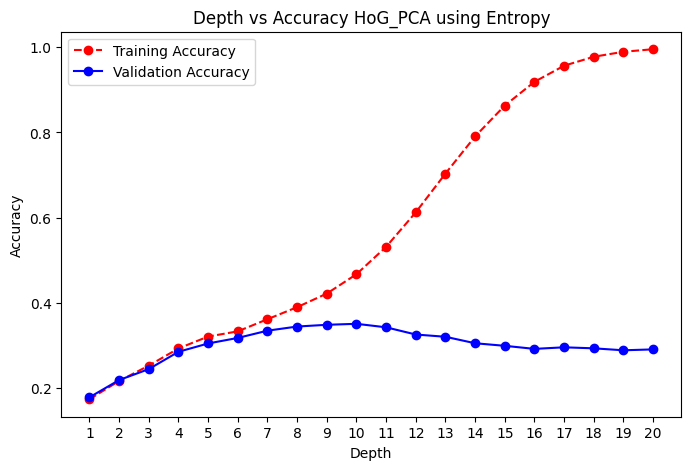

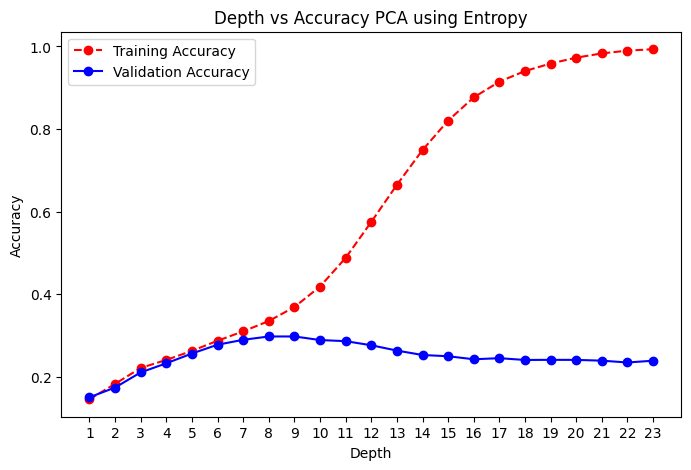

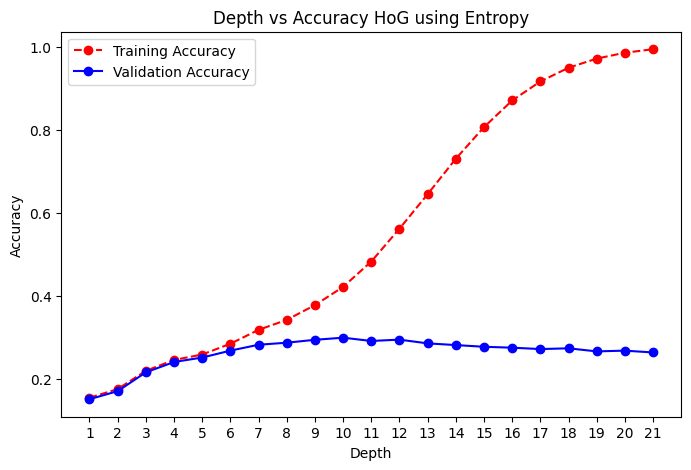

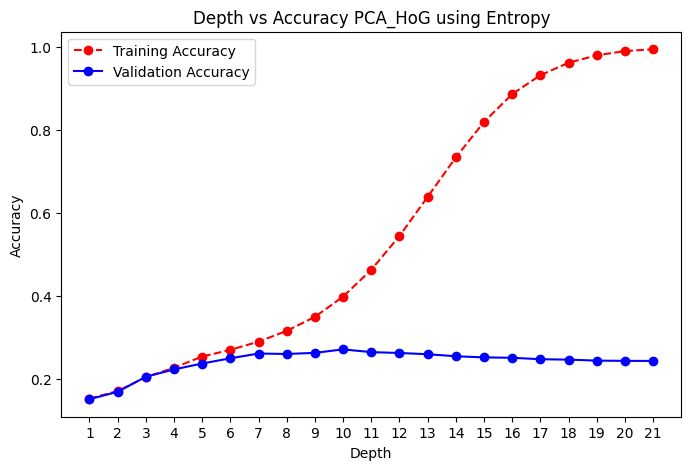

In [ ]:
plot_accuracies_vs_depths(range(1, MaxDepth_HoG_PCA+1), TrainAccuracies_HoG_PCA, ValidationAccuracies_HoG_PCA, 'HoG_PCA using Entropy')
plot_accuracies_vs_depths(range(1, MaxDepth_PCA+1), TrainAccuracies_PCA, ValidationAccuracies_PCA, 'PCA using Entropy')
plot_accuracies_vs_depths(range(1, MaxDepth_HoG+1), TrainAccuracies_HoG, ValidationAccuracies_HoG, 'HoG using Entropy')
plot_accuracies_vs_depths(range(1, MaxDepth_PCA_HoG+1), TrainAccuracies_PCA_HoG, ValidationAccuracies_PCA_HoG, 'PCA_HoG using Entropy')

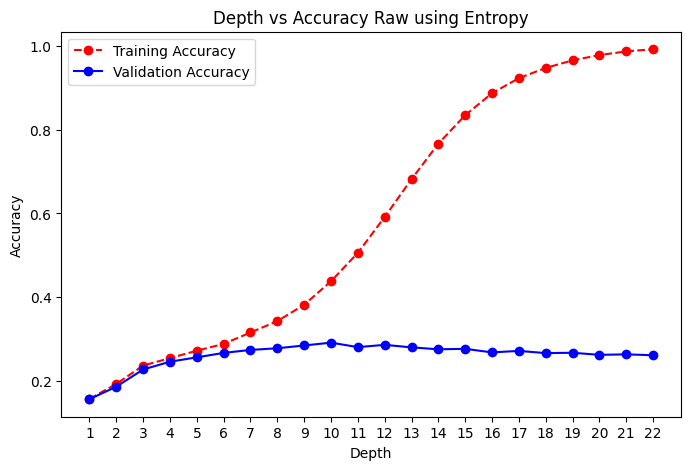

In [ ]:
plot_accuracies_vs_depths(range(1, MaxDepth_Raw+1), TrainAccuracies_Raw, ValidationAccuracies_Raw, 'Raw using Entropy')

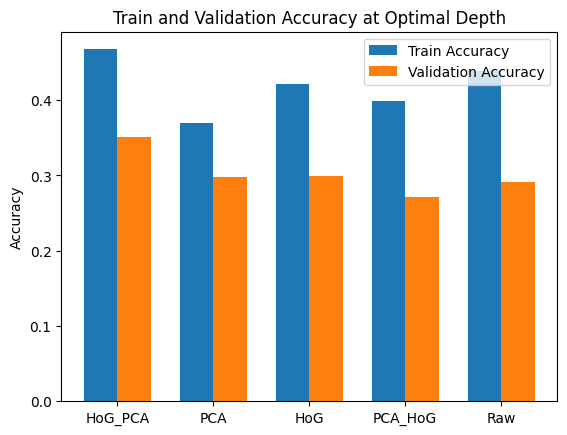

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

datasets = ['HoG_PCA', 'PCA', 'HoG', 'PCA_HoG', 'Raw']
optimal_depths = [10, 9, 10, 10, OptimalDepth_Raw]
train_accuracies = [0.467475, 0.36935, 0.421075, 0.398275, TrainAccuracies_Raw[OptimalDepth_Raw - 1]]
validation_accuracies = [0.3512, 0.2982, 0.2988, 0.2712, ValidationAccuracies_Raw[OptimalDepth_Raw - 1]]

bar_width = 0.35

fig, ax = plt.subplots()
bar1 = ax.bar(np.arange(len(datasets)), train_accuracies, bar_width, label='Train Accuracy')
bar2 = ax.bar(np.arange(len(datasets)) + bar_width, validation_accuracies, bar_width, label='Validation Accuracy')

ax.set_ylabel('Accuracy')
ax.set_title('Train and Validation Accuracy at Optimal Depth')
ax.set_xticks(np.arange(len(datasets)) + bar_width / 2)
ax.set_xticklabels(datasets)
ax.legend()

plt.show()

In [ ]:
print(train_accuracies)
print(validation_accuracies)

[0.467475, 0.36935, 0.421075, 0.398275]
[0.3512, 0.2982, 0.2988, 0.2712]


In [ ]:
print(train_accuracies[4])
print(validation_accuracies[4])

0.438
0.438


In [ ]:
from sklearn.tree import export_graphviz
import graphviz
from IPython.display import SVG
from google.colab import files
!pip install graphviz

def Save_decision_tree(tree, feature_names,filename) :

  num_features = feature_names.shape[1]

  feature_names = [f'feature_{i}' for i in range(num_features)]

  dotData = export_graphviz(tree, out_file=None,feature_names=feature_names,class_names = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9'],filled=True, rounded=True,special_characters=True)

  graph = graphviz.Source(dotData)

  graph.render(filename, format='svg')
  files.download(filename + '.svg')


In [ ]:
Save_decision_tree(OptimalTree_HoG_PCA, X_train[3], 'OptimalTree_HoG_PCA')
Save_decision_tree(OptimalTree_PCA, X_train[2], 'OptimalTree_PCA')
Save_decision_tree(OptimalTree_HoG, X_train[1], 'OptimalTree_HoG')
Save_decision_tree(OptimalTree_PCA_HoG, X_train[4], 'OptimalTree_PCA_HoG')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
Save_decision_tree(OptimalTree_Raw, X_train[0], 'OptimalTree_Raw')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
dot_data = export_graphviz(OptimalTree_HoG_PCA, out_file=None, feature_names=[f'feature_{i}' for i in range(X_train[3].shape[1])],
                           class_names=['0', '1', '2', '3', '4', '5', '6', '7', '8', '9'],
                           filled=True, rounded=True, special_characters=True)
graph = graphviz.Source(dot_data)
display(SVG(graph.pipe(format='svg')))